In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import numpy as np

In [3]:
data = pd.read_csv('PlayTennis.csv')
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [4]:
from sklearn.preprocessing import OrdinalEncoder
outlook_encoder = OrdinalEncoder()
data['Outlook'] = outlook_encoder.fit_transform(data[['Outlook']])

temp_encoder = OrdinalEncoder()
data['Temperature'] = temp_encoder.fit_transform(data[['Temperature']])

him_encoder = OrdinalEncoder()
data['Humidity'] = him_encoder.fit_transform(data[['Humidity']])

wind_encoder = OrdinalEncoder()
data['Wind'] = wind_encoder.fit_transform(data[['Wind']])

pt_encoder = OrdinalEncoder()
data['Play Tennis'] = pt_encoder.fit_transform(data[['Play Tennis']])



In [5]:
data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0
5,1.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,1.0
7,2.0,2.0,0.0,1.0,0.0
8,2.0,0.0,1.0,1.0,1.0
9,1.0,2.0,1.0,1.0,1.0


In [6]:
x =data.drop(['Play Tennis'] ,axis=1)
y =data['Play Tennis']

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(x_train,y_train)
y_pred= clf.predict(x_test)

In [9]:
clf1 = DecisionTreeClassifier(criterion='entropy')
clf1.fit(x_train,y_train)
y_pred_1= clf1.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy with Gini : ",accuracy_score(y_test,y_pred))
print("classification_report with Gini : ",classification_report(y_test,y_pred))
print("confusion_matrix with Gini : ",confusion_matrix(y_test,y_pred))

Accuracy with Gini :  1.0
classification_report with Gini :                precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

confusion_matrix with Gini :  [[1 0]
 [0 2]]


In [11]:
print("Accuracy with Gini : ",accuracy_score(y_test,y_pred_1))
print("classification_report with Gini : ",classification_report(y_test,y_pred_1))
print("confusion_matrix with Gini : ",confusion_matrix(y_test,y_pred_1))


Accuracy with Gini :  1.0
classification_report with Gini :                precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

confusion_matrix with Gini :  [[1 0]
 [0 2]]


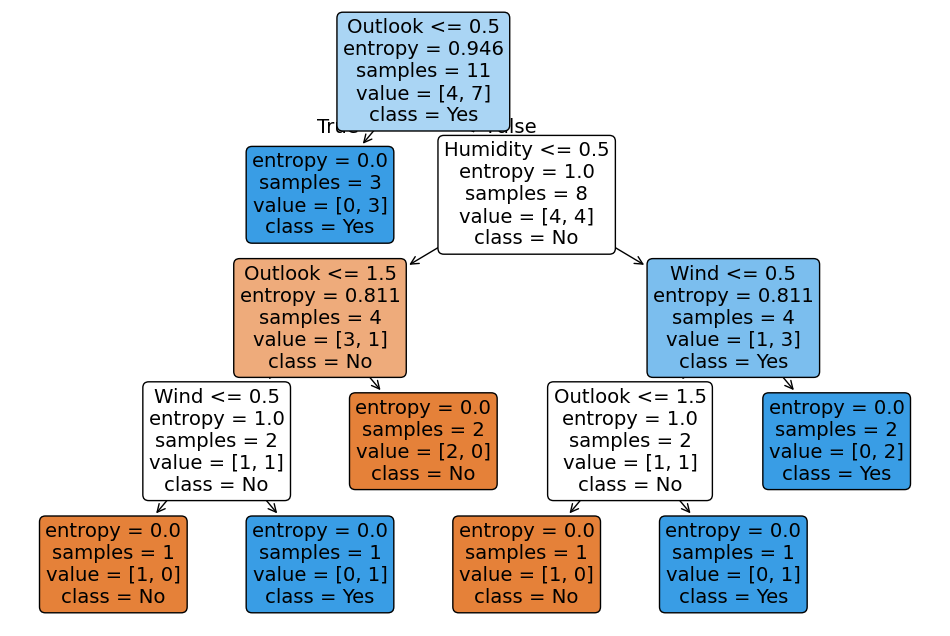

In [ ]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf1,filled=True ,feature_names=x.columns ,class_names=pt_encoder.categories_[0] ,rounded=True)
plt.show()

